In [ ]:
import os
# Limit OS-level process affinity to exclusively use Core 0.
# This strictly physically constraints Polars, PyTorch, and everything else in this notebook to 1 core.
os.sched_setaffinity(0, {2,3})

# Also keep your GPU and general thread limits just in case
os.environ["CUDA_VISIBLE_DEVICES"] = "1" 
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["POLARS_MAX_THREADS"] = "2"

In [1]:
#reload mlp and data_preparation
%load_ext autoreload
%autoreload 2
from mlp_lstm import DataPreparation, MultiLayerPerceptron

In [9]:
#load libs
import lightning as L
import polars as pl
import torch
import subprocess
import time
from datetime import date
import optuna
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

In [3]:
df_tfidf = (
    pl.scan_parquet('/mnt/windows/windows_hanka_bcthesis/full_news/tfidf_nasdaq.parquet')
    # Use whatever the date column is actually called in this file
    .filter(pl.col("trading_session_date_utc").is_between(pl.date(2006, 10, 20), pl.date(2019, 12, 31)))
    .collect()
)

# Use scan_parquet() -> filter() -> collect()
df_sent = (
    pl.scan_parquet('/mnt/red/red_hanka_bcthesis/full_news/finbert_nasdaq_2006-2023_avg_sentiment.parquet')
    # Use whatever the date column is actually called in this file
    .filter(pl.col("trading_session_date_utc").is_between(pl.date(2006, 10, 20), pl.date(2019, 12, 31)))
    .collect()
)

df_emb = (
    pl.scan_parquet('/mnt/red/red_hanka_bcthesis/full_news/finbert_nasdaq_2006-2023_avg_embeddings.parquet')
    # Use whatever the date column is actually called in this file
    .filter(pl.col("trading_session_date_utc").is_between(pl.date(2006, 10, 20), pl.date(2019, 12, 31)))
    .collect()
)

# 1. Load the 5 individual stock dataframes
df_aapl = pl.scan_csv('/mnt/windows/windows_hanka_bcthesis/full_stock_prices/AAPL.csv').with_columns(pl.col('date').str.to_date('%Y-%m-%d')).collect()
df_msft = pl.scan_csv('/mnt/windows/windows_hanka_bcthesis/full_stock_prices/MSFT.csv').with_columns(pl.col('date').str.to_date('%Y-%m-%d')).collect()
df_googl = pl.scan_csv('/mnt/windows/windows_hanka_bcthesis/full_stock_prices/GOOGL.csv').with_columns(pl.col('date').str.to_date('%Y-%m-%d')).collect()
df_amzn = pl.scan_csv('/mnt/windows/windows_hanka_bcthesis/full_stock_prices/AMZN.csv').with_columns(pl.col('date').str.to_date('%Y-%m-%d')).collect()
df_nvda = pl.scan_csv('/mnt/windows/windows_hanka_bcthesis/full_stock_prices/NVDA.csv').with_columns(pl.col('date').str.to_date('%Y-%m-%d')).collect() # Or FB.csv

# Package them up
dict_of_dfs = {
    "AAPL": df_aapl.select(['date', 'close']),
    "MSFT": df_msft.select(['date', 'close']),
    "GOOGL": df_googl.select(['date', 'close']),
    "AMZN": df_amzn.select(['date', 'close']),
    "NVDA": df_nvda.select(['date', 'close'])
}

In [4]:
DataPrepObject = DataPreparation()

In [6]:
# 1. Base Layer: Prices
DataPrepObject.load_and_prepare_multiple_price_data(dict_of_dfs, start_date=date(2006, 10, 20), end_date=date(2019, 12, 31)) 
DataPrepObject.load_finbert_embeddings_data(df_emb, n_components=60)
DataPrepObject.load_tfidf_data(df_tfidf, n_components=100)
DataPrepObject.load_finbert_sentiment_data(df_sent)

Loading prices for multiple stocks: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']...
Master multi-stock timeline established. Shape: (16570, 9)
Loading FinBERT embeddings. Applying PCA to reduce to 60 dimensions...
Embeddings shape: (3570, 768)
PCA reducing to 60 components...
Embeddings PCA applied. Total cols in master: 69
Loading TF-IDF data and aligning with timeline...
TF-IDF aligned & PCA applied. Total columns in master: 169
Loading FinBERT sentiment data and aligning with timeline...
FinBERT aligned. Total columns in master: 173


trading_date_utc,ticker,target_next_day,return_lag0,return_lag1,return_lag2,return_lag3,return_lag4,return_lag5,emb_pca_0,emb_pca_1,emb_pca_2,emb_pca_3,emb_pca_4,emb_pca_5,emb_pca_6,emb_pca_7,emb_pca_8,emb_pca_9,emb_pca_10,emb_pca_11,emb_pca_12,emb_pca_13,emb_pca_14,emb_pca_15,emb_pca_16,emb_pca_17,emb_pca_18,emb_pca_19,emb_pca_20,emb_pca_21,emb_pca_22,emb_pca_23,emb_pca_24,emb_pca_25,emb_pca_26,emb_pca_27,…,pca_67,pca_68,pca_69,pca_70,pca_71,pca_72,pca_73,pca_74,pca_75,pca_76,pca_77,pca_78,pca_79,pca_80,pca_81,pca_82,pca_83,pca_84,pca_85,pca_86,pca_87,pca_88,pca_89,pca_90,pca_91,pca_92,pca_93,pca_94,pca_95,pca_96,pca_97,pca_98,pca_99,avg_pos,avg_neg,avg_neu,daily_article_count
date,str,f64,f64,f64,f64,f64,f64,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f32,f64
2006-10-30,"""AAPL""",1.0,0.000124,-0.021657,0.006244,0.007773,-0.005033,0.018887,-0.408383,-1.51191,-0.553568,-0.467821,0.229624,1.282504,0.336446,0.298169,0.521651,-0.246513,0.051765,-0.367064,0.676642,-0.943535,-1.565873,0.409516,-1.291347,0.0126,0.452128,0.449509,0.783125,-0.597398,-0.01653,-0.385904,0.588087,-0.455045,0.240922,-0.957294,…,-0.033041,-0.077107,-0.081145,0.001221,0.005378,-0.202098,0.019207,0.002819,-0.085189,-0.015426,-0.231756,-0.007704,0.194813,0.024952,-0.149711,-0.122173,-0.074393,0.010132,0.175068,-0.248368,0.113149,-0.000719,-0.091126,0.039586,0.159927,-0.159679,0.067785,0.215793,-0.055038,-0.136895,-0.06458,0.030384,-0.162301,0.095434,0.389893,0.514862,3.0
2006-10-31,"""AAPL""",0.0,0.008207,0.000124,-0.021657,0.006244,0.007773,-0.005033,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2006-11-01,"""AAPL""",0.0,-0.02368,0.008207,0.000124,-0.021657,0.006244,0.007773,0.319845,0.182709,1.528221,0.189535,-0.774229,0.712789,-0.266697,0.082364,0.928731,-0.204755,0.463394,-0.335497,0.838686,-1.366572,-0.914557,0.183932,-0.041732,0.059874,-0.081781,0.35008,0.900571,-0.090204,0.359838,0.419868,0.095423,-0.237157,0.339387,-0.993111,…,0.03144,-0.092047,0.031963,0.006825,0.001228,-0.099349,0.001035,-0.097887,-0.021887,-0.033445,-0.085223,0.023767,0.033447,0.106589,0.064916,-0.063751,-0.054757,-0.026575,-0.025784,-0.066126,0.00008,0.047287,-0.07426,-0.013624,0.07201,0.082622,0.022536,0.163493,-0.06019,-0.039727,-0.169715,-0.017364,-0.210846,0.405802,0.040825,0.553304,3.0
2006-11-02,"""AAPL""",0.0,-0.002274,-0.02368,0.008207,0.000124,-0.021657,0.006244,-2.478588,0.766764,2.102778,2.434615,-1.38606,-0.541972,-1.325683,-1.703224,-0.60222,1.622953,-1.172049,0.089778,0.777859,0.892529,0.993805,0.704141,1.045472,0.364383,0.800517,0.320315,0.682748,0.215434,0.090245,0.80388,0.156785,-0.465599,0.941877,0.746108,…,-0.066041,-0.073327,0.071475,-0.081009,0.00518,-0.055135,0.002095,0.080421,-0.098582,-0.232271,-0.123279,0.068841,-0.14462,-0.046077,-0.059769,0.04869,-0.094601,0.127512,0.232253,0.056012,-0.041571,0.119415,-0.12126,0.179455,-0.062016,0.144932,-0.000257,-0.083673,0.055507,0.120938,0.105711,-0.01142,0.120108,0.792236,0.048584,0.15918,2.0
2006-11-03,"""AAPL""",1.0,-0.008736,-0.002274,-0.02368,0.008207,0.000124,-0.021657,-2.76324,-2.556471,-0.77067,-0.166453,-0.526264,1.303837,-0.260792,-0.03108,-0.734412,-0.812854,-0.363056,-0.087761,-0.434892,0.79394,0.742792,0.446526,-0.028515,0.043933,-0.584662,-0.257993,0.167012,-0.299309,0.068721,-1.39276,0.284477,-0.074972,0.124122,0.108924,…,-0.171051,0.025462,-0.03412,-0.274188,0.015087,0.054244,-0.067945,0.093321,0.074705,-0.136712,-0.017946,0.046123,0.000322,-0.022711,-0.015727,0.017514,0.134958,0.147669,0.146444,-0.235375,0.040533,0.117717,0.183866,-0.088761,0.071649,-0.046598,-0.071683,-0.21290

In [ ]:
# test 2nd Optuna optimized run (MLP) results
study_name = "universal_mlp_v1"
storage_name = "sqlite:///optuna_universal_mlp.db"

study = optuna.load_study(study_name=study_name, storage=storage_name)

# Extract all trials into a DataFrame
df_trials = study.trials_dataframe()

# Filter out PRUNED or FAILED trials, keep only COMPLETE
df_completed = df_trials[df_trials['state'] == 'COMPLETE']
# Sort by best Validation Accuracy (descending) and grab Top 10
df_optuna_mlp_top = df_completed.sort_values(by='value', ascending=False).head(10)

# Clean up the output to only show metrics and parameters
cols_to_show = ['value'] + \
               [c for c in df_optuna_mlp_top.columns if c.startswith('params_')]

# Rename 'value' to 'val_acc' for readability
df_optuna_mlp_top = df_optuna_mlp_top[cols_to_show].rename(columns={'value': 'val_acc'})

# Display nicely in Jupyter
display(df_optuna_mlp_top)

,val_acc,params_batch_size,params_dropout,params_hidden_size,params_learning_rate,params_mode,params_weight_decay
187,0.611565,32,0.540013,256,0.005851,finbert_emb,0.000429
306,0.601111,32,0.537539,256,0.007763,finbert_emb,0.000355
303,0.601111,32,0.573029,256,0.007166,finbert_emb,0.000404
346,0.601111,32,0.540416,256,0.008084,finbert_emb,0.000550
300,0.599804,32,0.549702,256,0.006029,finbert_emb,0.000435
70,0.594577,32,0.343365,256,0.005921,finbert_emb,0.001266
338,0.591963,32,0.516193,256,0.005777,finbert_emb,0.000929
289,0.591963,32,0.564779,256,0.006250,finbert_emb,0.000374
291,0.590657,32,0.559441,256,0.005454,finbert_emb,0.000433
354,0.590657,32,0.570079,256,0.008316,tfidf_hybrid,0.000527


In [ ]:
# test 2nd Optuna optimized run (MLP) results
# select top 5 models by validation accuracy and test them
top_optuna_mlp_models = df_optuna_mlp_top.head(5)

models_to_test = []
for idx, row in top_optuna_mlp_models.iterrows():
    models_to_test.append({
        "name": f"({row['val_acc']*100:.2f}%) - nmb {idx}",
        "hidden_size": row['params_hidden_size'],
        "dropout": row['params_dropout'],
        "learning_rate": row['params_learning_rate'],
        "weight_decay": row['params_weight_decay'],
        "batch_size": row['params_batch_size'],
        "mode": row['params_mode'],
    })

results = []

for config in models_to_test:
    mode = config["mode"]
    run_name = f"trial {config['name']} | mode={mode}"
    print(f"\n{'='*80}\nOOS TESTING: {run_name}\n{'='*80}")

    df_master, X_tensor, y_tensor = DataPrepObject.get_mlp_tensors(mode=mode)
    train_loader, val_loader, test_loader, num_features = DataPrepObject.split_mlp_data(
        X_tensor, y_tensor, 
        train_ratio=0.60, # ~2006-2013
        val_ratio=0.15,   # ~2014-2015
        batch_size=config["batch_size"]
    )
    
    train_loader, val_loader, test_loader, num_features = DataPrepObject.split_mlp_data(
        X_tensor, y_tensor, 
        train_ratio=0.60, 
        val_ratio=0.15,
        batch_size=config["batch_size"]
    )
    
    model = MultiLayerPerceptron(
        input_size=num_features,
        hidden_size=config["hidden_size"],
        dropout_rate=config["dropout"],
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )
    
    early_stop = EarlyStopping(
        monitor="val_acc", 
        min_delta=0.00, 
        patience=30, 
        mode="max",
        verbose=False
    )
    
    trainer = L.Trainer(
        max_epochs=150,
        accelerator="gpu",   
        devices=[0], 
        callbacks=[early_stop],
        enable_progress_bar=False,
        logger=False # Keeps terminal fully clean overnight
    )
    
    trainer.fit(model, train_loader, val_loader)
    
    best_val_acc = trainer.callbacks[0].best_score.item() 


    # RUN THE OUT OF SAMPLE TEST! 
    print("Running strict Out-Of-Sample evaluation on untouched data...")
    test_metrics = trainer.test(model, dataloaders=test_loader, verbose=False)[0]

    # Store the final truth
    results.append({
        "Run": run_name,
        "Test_Acc": test_metrics.get("test_acc", 0.0),
        "Test_AUC": test_metrics.get("test_auroc", 0.0),
        "Best_Val_Acc": trainer.callbacks[0].best_score.item()
    })

# Print Leaderboard
print("\n" + "="*50)
print("FINAL OUT-OF-SAMPLE (OOS) LEADERBOARD")
print("="*50)
for r in sorted(results, key=lambda x: x["Test_Acc"], reverse=True):
    print(f"OOS Accuracy: {r['Test_Acc']:.4f} | OOS AUC: {r['Test_AUC']:.4f} | (Val Acc: {r['Best_Val_Acc']:.4f}) -> {r['Run']}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/sj5/.micromamba/envs/thesis_dl_2/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/sj5/Documents/linux_hanka_bcthesis/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]



OOS TESTING: trial (61.16%) - nmb 187 | mode=finbert_emb
Preparing Tensors for mode 'finbert_emb' with 60 features...
Train: torch.Size([12246, 60]), Val: torch.Size([3061, 60]), Test: torch.Size([5103, 60])
Train: torch.Size([12246, 60]), Val: torch.Size([3061, 60]), Test: torch.Size([5103, 60])


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name        ┃ Type              ┃ Params ┃ Mode  ┃  FLOPs ┃ In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ model       │ Sequential        │ 48.6 K │ train │ 96.5 K │  [1, 60] │    [1, 1] │
│ 1 │ loss_fn     │ BCEWithLogitsLoss │      0 │ train │      0 │        ? │         ? │
│ 2 │ train_acc   │ BinaryAccuracy    │      0 │ train │      0 │        ? │         ? │
│ 3 │ val_acc     │ BinaryAccuracy    │      0 │ train │      0 │        ? │         ? │
│ 4 │ test_acc    │ BinaryAccuracy    │      0 │ train │      0 │        ? │         ? │
│ 5 │ train_auroc │ BinaryAUROC       │      0 │ train │      0 │        ? │         ? │
│ 6 │ val_auroc   │ BinaryAUROC       │      0 │ train │      0 │        ? │         ? │
│ 7 │ test_auroc  │ BinaryAUROC       │      0 │ train │      0 │        ? │         ? │
└───┴─────────────┴───────────────────┴────────┴───────┴────────┴──────────┴───────────┘

Trainable params: 48.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 48.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 96.5 K

/home/sj5/.micromamba/envs/thesis_dl_2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/home/sj5/.micromamba/envs/thesis_dl_2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/home/sj5/.micromamba/envs/thesis_dl_2/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)
/home/sj5/.micromamba/envs/thesis_dl_2/lib/python3.11/site-packages/tor

...


OOS TESTING: trial (59.98%) - nmb 300 | mode=finbert_emb
Preparing Tensors for mode 'finbert_emb' with 60 features...
Train: torch.Size([12246, 60]), Val: torch.Size([3061, 60]), Test: torch.Size([5103, 60])
Train: torch.Size([12246, 60]), Val: torch.Size([3061, 60]), Test: torch.Size([5103, 60])


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name        ┃ Type              ┃ Params ┃ Mode  ┃  FLOPs ┃ In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ model       │ Sequential        │ 48.6 K │ train │ 96.5 K │  [1, 60] │    [1, 1] │
│ 1 │ loss_fn     │ BCEWithLogitsLoss │      0 │ train │      0 │        ? │         ? │
│ 2 │ train_acc   │ BinaryAccuracy    │      0 │ train │      0 │        ? │         ? │
│ 3 │ val_acc     │ BinaryAccuracy    │      0 │ train │      0 │        ? │         ? │
│ 4 │ test_acc    │ BinaryAccuracy    │      0 │ train │      0 │        ? │         ? │
│ 5 │ train_auroc │ BinaryAUROC       │      0 │ train │      0 │        ? │         ? │
│ 6 │ val_auroc   │ BinaryAUROC       │      0 │ train │      0 │        ? │         ? │
│ 7 │ test_auroc  │ BinaryAUROC       │      0 │ train │      0 │        ? │         ? │
└───┴─────────────┴───────────────────┴────────┴───────┴────────┴──────────┴───────────┘

Trainable params: 48.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 48.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 96.5 K

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Running strict Out-Of-Sample evaluation on untouched data...

FINAL OUT-OF-SAMPLE (OOS) LEADERBOARD
OOS Accuracy: 0.5393 | OOS AUC: 0.5051 | (Val Acc: 0.5619) -> trial (60.11%) - nmb 306 | mode=finbert_emb
OOS Accuracy: 0.5387 | OOS AUC: 0.4792 | (Val Acc: 0.5645) -> trial (60.11%) - nmb 346 | mode=finbert_emb
OOS Accuracy: 0.5295 | OOS AUC: 0.5075 | (Val Acc: 0.5593) -> trial (60.11%) - nmb 303 | mode=finbert_emb
OOS Accuracy: 0.5136 | OOS AUC: 0.5115 | (Val Acc: 0.5645) -> trial (61.16%) - nmb 187 | mode=finbert_emb
OOS Accuracy: 0.4797 | OOS AUC: 0.5095 | (Val Acc: 0.5867) -> trial (59.98%) - nmb 300 | mode=finbert_emb


In [ ]:
#Starting TensorBoard to visualize training logs
# Verify the log directory exists
#log_dir = '/home/sj5/Documents/hanka_bcthesis/lightning_logs'
log_dir = '/mnt/red/red_hanka_bcthesis/lightning_logs'
if os.path.exists(log_dir):
    print(f"✓ Log directory found: {log_dir}")
    # List subdirectories (each training run)
    runs = [d for d in os.listdir(log_dir) if os.path.isdir(os.path.join(log_dir, d))]
    print(f"  Available runs: {runs if runs else 'No runs yet - train a model first!'}")
else:
    print(f"✗ Log directory not found: {log_dir}")
    print("  Train a model first to create logs")

# Kill any existing TensorBoard processes
subprocess.run(['pkill', '-f', 'tensorboard'], stderr=subprocess.DEVNULL)
time.sleep(1)

# Start TensorBoard
process = subprocess.Popen([
    'tensorboard',
    '--logdir', log_dir,
    '--host', '0.0.0.0',
    '--port', '6006'
], stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

time.sleep(2)
if process.poll() is not None:
    stdout, stderr = process.communicate()
    print("❌ Error starting TensorBoard:")
    print(stderr)
else:
    print("\n✓ TensorBoard started at http://localhost:6006/")
    print("  (Check VS Code PORTS tab to ensure port 6006 is forwarded)")

✓ Log directory found: /mnt/windows/hanka_bcthesis/lightning_logs
  Available runs: ['version_0', 'version_1', 'version_10', 'version_11', 'version_12', 'version_13', 'version_14', 'version_15', 'version_16', 'version_17', 'version_18', 'version_19', 'version_2', 'version_20', 'version_21', 'version_22', 'version_23', 'version_24', 'version_25', 'version_26', 'version_3', 'version_4', 'version_5', 'version_6', 'version_7', 'version_8', 'version_9']

✓ TensorBoard started at http://localhost:6006/
  (Check VS Code PORTS tab to ensure port 6006 is forwarded)


In [ ]:
# test 1st Optuna optimized run (MLP) results
models_to_test = [
    {
        "name": "(54.48%) - nmb 81",
        "hidden_size": 128, "dropout": 0.331270, "learning_rate": 0.001033,
        "weight_decay": 0.000060, "batch_size": 32, "mode": "finbert_sent"
    },
    {
        "name": "(54.26%) - nmb 102",
        "hidden_size": 128, "dropout": 0.323476, "learning_rate": 0.000528,
        "weight_decay": 0.000089, "batch_size": 32, "mode": "finbert_sent"
    },
    {
        "name": "(54.26%) - nmb 254",
        "hidden_size": 128, "dropout": 0.321854, "learning_rate": 0.000481,
        "weight_decay": 0.000053, "batch_size": 128, "mode": "finbert_sent"
    },
    {
        "name": "(54.15%) - nmb 73",
        "hidden_size": 128, "dropout": 0.366596, "learning_rate": 0.000684,
        "weight_decay": 0.000081, "batch_size": 32, "mode": "finbert_sent"
    }
]

results = []

for config in models_to_test:
    mode = config["mode"]
    run_name = f"trial {config['name']} | mode={mode}"
    print(f"\n{'='*80}\nOOS TESTING: {run_name}\n{'='*80}")

    # MLP tensors (2D)
    df_master, X_tensor, y_tensor = DataPrepObject.get_mlp_tensors(mode=mode)
    train_loader, val_loader, test_loader, num_features = DataPrepObject.split_mlp_data(
        X_tensor, y_tensor,
        train_ratio=0.60,
        val_ratio=0.15,
        batch_size=config["batch_size"]
    )

    model = MultiLayerPerceptron(
        input_size=num_features,
        hidden_size=config["hidden_size"],
        dropout_rate=config["dropout"],
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )

    early_stop = EarlyStopping(
        monitor='val_acc',
        min_delta=0.00,
        patience=15,
        mode='max',
        verbose=True
    )

    trainer = L.Trainer(
        max_epochs=120,
        callbacks=[early_stop],
        logger=False,
        accelerator="gpu",
        devices=[0],
        enable_progress_bar=False,
        enable_model_summary=False
    )

    print("\n--- Starting MLP Training ---")
    trainer.fit(model, train_loader, val_loader)

    print("Running strict Out-Of-Sample evaluation on untouched data...")
    test_metrics = trainer.test(model, dataloaders=test_loader, verbose=False)[0]

    #best_val_acc = early_stop.best_score.item() if early_stop.best_score is not None else float("nan")

    results.append({
        "Run": run_name,
        "Test_Acc": test_metrics.get("test_acc", 0.0),
        "Test_AUC": test_metrics.get("test_auroc", 0.0),
        "Best_Val_Acc": trainer.callbacks[0].best_score.item()
    })

print("\n" + "="*50)
print("FINAL MLP OUT-OF-SAMPLE (OOS) LEADERBOARD")
print("="*50)
for r in sorted(results, key=lambda x: x["Test_Acc"], reverse=True):
    print(f"OOS Accuracy: {r['Test_Acc']:.4f} | OOS AUC: {r['Test_AUC']:.4f} | (Val Acc: {r['Best_Val_Acc']:.4f}) -> {r['Run']}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Loading Universal multi-stock data for MLP OOS testing...
Loading prices for multiple stocks: ['AAPL', 'MSFT', 'GOOGL']...
Master multi-stock timeline established. Shape: (6168, 9)
Loading FinBERT sentiment data and aligning with timeline...
FinBERT aligned. Total columns in master: 13

OOS TESTING: trial (54.48%) - nmb 81 | mode=finbert_sent
Preparing Tensors for mode 'finbert_sent' with 4 features...
Train: torch.Size([3704, 4]), Val: torch.Size([926, 4]), Test: torch.Size([1544, 4])

--- Starting MLP Training ---


Metric val_acc improved. New best score: 0.500
Metric val_acc improved by 0.017 >= min_delta = 0.0. New best score: 0.517
Metric val_acc improved by 0.004 >= min_delta = 0.0. New best score: 0.522
Metric val_acc improved by 0.008 >= min_delta = 0.0. New best score: 0.529
Metric val_acc improved by 0.001 >= min_delta = 0.0. New best score: 0.530
Metric val_acc improved by 0.005 >= min_delta = 0.0. New best score: 0.536
Metric val_acc improved by 0.008 >= min_delta = 0.0. New best score: 0.543
Monitored metric val_acc did not improve in the last 15 records. Best score: 0.543. Signaling Trainer to stop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Running strict Out-Of-Sample evaluation on untouched data...


/home/sj5/.micromamba/envs/thesis_dl_2/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


...


OOS TESTING: trial (54.26%) - nmb 254 | mode=finbert_sent
Preparing Tensors for mode 'finbert_sent' with 4 features...
Train: torch.Size([3704, 4]), Val: torch.Size([926, 4]), Test: torch.Size([1544, 4])

--- Starting MLP Training ---


Metric val_acc improved. New best score: 0.505
Metric val_acc improved by 0.019 >= min_delta = 0.0. New best score: 0.525
Metric val_acc improved by 0.005 >= min_delta = 0.0. New best score: 0.530
Metric val_acc improved by 0.001 >= min_delta = 0.0. New best score: 0.531
Metric val_acc improved by 0.005 >= min_delta = 0.0. New best score: 0.537
Metric val_acc improved by 0.003 >= min_delta = 0.0. New best score: 0.540
Monitored metric val_acc did not improve in the last 15 records. Best score: 0.540. Signaling Trainer to stop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/)

Running strict Out-Of-Sample evaluation on untouched data...

OOS TESTING: trial (54.15%) - nmb 73 | mode=finbert_sent
Preparing Tensors for mode 'finbert_sent' with 4 features...
Train: torch.Size([3704, 4]), Val: torch.Size([926, 4]), Test: torch.Size([1544, 4])

--- Starting MLP Training ---


Metric val_acc improved. New best score: 0.508
Metric val_acc improved by 0.019 >= min_delta = 0.0. New best score: 0.527
Metric val_acc improved by 0.006 >= min_delta = 0.0. New best score: 0.533
Metric val_acc improved by 0.001 >= min_delta = 0.0. New best score: 0.535
Metric val_acc improved by 0.005 >= min_delta = 0.0. New best score: 0.540
Metric val_acc improved by 0.002 >= min_delta = 0.0. New best score: 0.542
Monitored metric val_acc did not improve in the last 15 records. Best score: 0.542. Signaling Trainer to stop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Running strict Out-Of-Sample evaluation on untouched data...

FINAL MLP OUT-OF-SAMPLE (OOS) LEADERBOARD
OOS Accuracy: 0.5019 | OOS AUC: 0.5030 | (Val Acc: 0.5421) -> trial (54.15%) - nmb 73 | mode=finbert_sent
OOS Accuracy: 0.4948 | OOS AUC: 0.4989 | (Val Acc: 0.5432) -> trial (54.48%) - nmb 81 | mode=finbert_sent
OOS Accuracy: 0.4948 | OOS AUC: 0.4945 | (Val Acc: 0.5400) -> trial (54.26%) - nmb 254 | mode=finbert_sent
OOS Accuracy: 0.4870 | OOS AUC: 0.4989 | (Val Acc: 0.5421) -> trial (54.26%) - nmb 102 | mode=finbert_sent


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/sj5/.micromamba/envs/thesis_dl_2/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.
Finding best initial lr: 100%|██████████| 100/100 [00:00<00:00, 172.54it/s]
Restoring states from the checkpoint path at /home/sj5/Documents/hanka_bcthesis/.lr_find_db6fea75-fa40-4cfc-ab

lr_find() suggests: 0.010964781961431852


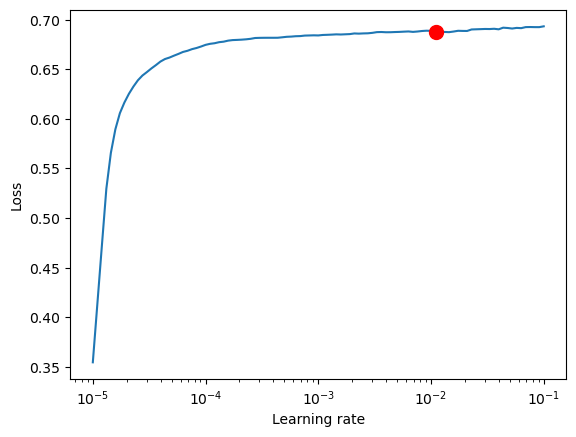

In [ ]:
# find optimal learning rate using lr_find
# 1. Initialize model (Turn off dropout for now to make learning easier)
model = MultiLayerPerceptron(input_size=num_features, hidden_size=64, dropout_rate=0.2)

# 2. Initialize trainer
trainer = L.Trainer(max_epochs=50, log_every_n_steps=10)

# 3. Run the Tuner
tuner = L.pytorch.tuner.Tuner(trainer)
lr_finder = tuner.lr_find(
    model, 
    train_dataloaders=train_loader, 
    min_lr=1e-5, 
    max_lr=0.1, 
    early_stop_threshold=None
)

# 4. Get and print the suggestion
new_lr = lr_finder.suggestion()
print(f"lr_find() suggests: {new_lr}")

# 5. Plot the results to see the loss curve
fig = lr_finder.plot(suggest=True)
fig.show()